# SAMOS pipeline walkthrough — Step05

This notebook documents **Step05** of the SAMOS pipeline: pixel-flat construction.

Step05 uses the quartz difference images together with the Step04 slit masks to build the **pixel-to-pixel flat-field correction** for the detector. Its purpose is to isolate the small-scale detector response variations after removing the large-scale quartz illumination pattern.

This notebook is meant to make the infrastructure explicit and practical:

- where Step05 lives in the pipeline
- which config paths it reads
- which files it expects from Step04 and Step03.5
- how to run it robustly from a notebook
- what it writes for EVEN and ODD
- how to inspect the QC products


In [1]:
from pathlib import Path
import os
import sys

def find_repo_root(start: Path):
    candidates = [start] + list(start.parents)
    for p in candidates:
        cfg_dir = p / "config"
        if cfg_dir.is_dir() and (cfg_dir / "__init__.py").exists():
            return p
    return None

repo_env = os.environ.get("SAMOS_REPO_ROOT", "").strip()
if repo_env:
    REPO_ROOT = Path(repo_env).expanduser().resolve()
else:
    REPO_ROOT = find_repo_root(Path.cwd())

if REPO_ROOT is None:
    raise RuntimeError(
        "Could not find the SAMOS repository root. "
        "Run this notebook from inside the repo tree, or set SAMOS_REPO_ROOT."
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import config

print("Repo root        :", REPO_ROOT)
print("Step03.5 input   :", config.ST03P5_ROWSTRIPE)
print("Step04 output dir:", config.ST04_TRACES)
print("Step05 output dir:", config.ST05_PIXFLAT)
print("Quartz OFF       :", config.QUARTZ_SLITS_OFF)
print("Quartz ON EVEN   :", config.QUARTZ_SLITS_ON_EVEN)
print("Quartz ON ODD    :", config.QUARTZ_SLITS_ON_ODD)
print("PIXFLAT_EVEN     :", getattr(config, "PIXFLAT_EVEN", "not defined"))
print("PIXFLAT_ODD      :", getattr(config, "PIXFLAT_ODD", "not defined"))


Repo root        : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
Step03.5 input   : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/20260113/preprocessed/03p5_rowstripe
Step04 output dir: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/04_traces
Step05 output dir: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/05_pixflat
Quartz OFF       : 038.quartz_biascorr_cr_rowcorr.fits
Quartz ON EVEN   : 039.quartz_biascorr_cr_rowcorr.fits
Quartz ON ODD    : 040.quartz_biascorr_cr_rowcorr.fits
PIXFLAT_EVEN     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massim

## Notebook infrastructure

This notebook may live outside the repository root, for example under `drivers/Jupyter/`.  
Because of that, all pipeline and QC scripts should be executed through a helper that resolves paths relative to `REPO_ROOT`, not relative to the notebook working directory.

That is the main infrastructure rule for the notebooks going forward.


In [2]:
from pathlib import Path
import subprocess
import os
import sys

PYTHON = sys.executable

def run_repo_script(relpath: str, *args, check: bool = True):
    script = REPO_ROOT / relpath
    if not script.exists():
        raise FileNotFoundError(f"Script not found: {script}")

    env = os.environ.copy()
    old_pp = env.get("PYTHONPATH", "")
    env["PYTHONPATH"] = str(REPO_ROOT) + (os.pathsep + old_pp if old_pp else "")

    cmd = [PYTHON, str(script), *map(str, args)]
    print("Running:", " ".join(cmd))
    print("cwd     :", REPO_ROOT)
    print("PYTHONPATH:", env["PYTHONPATH"])

    return subprocess.run(
        cmd,
        check=check,
        cwd=str(REPO_ROOT),
        env=env,
    )

def repo_path(relpath: str) -> Path:
    return REPO_ROOT / relpath


## 1. Purpose of Step05

Step05 builds the detector **pixel flat**, not the slit illumination model itself.

For each slit family, the logic is:

```text
quartz_diff = Quartz_B - Quartz_A
illum2d     = heavily smoothed quartz_diff inside the slit mask
pixflat     = quartz_diff / illum2d
```

Then the result is clipped and renormalized so that the median correction is about 1.

In words:

- the quartz difference image gives the observed slit illumination
- a very smoothed version gives the large-scale illumination pattern
- dividing the two leaves the small-scale pixel-to-pixel response

That is the classic flat-field logic.


## 2. Dependencies and file flow

Step05 depends directly on two earlier pieces of infrastructure.

### From Step03.5
It reads the row-stripe corrected quartz inputs from:

- `config.ST03P5_ROWSTRIPE`

using these config entries:

- `config.QUARTZ_SLITS_OFF`
- `config.QUARTZ_SLITS_ON_EVEN`
- `config.QUARTZ_SLITS_ON_ODD`

### From Step04
It uses the slit masks from:

- `config.ST04_TRACES`

with this selection logic:

- prefer `*_mask_reg.fits` if present
- otherwise fall back to `*_mask.fits`

So the practical dependency chain is:

```text
Step03.5 quartz products + Step04 trace masks  →  Step05 pixel flat
```


In [3]:
# Quick check that the required inputs exist
from pathlib import Path

st03p5 = Path(config.ST03P5_ROWSTRIPE)
st04 = Path(config.ST04_TRACES)

required = [
    st03p5 / Path(config.QUARTZ_SLITS_OFF).name,
    st03p5 / Path(config.QUARTZ_SLITS_ON_EVEN).name,
    st03p5 / Path(config.QUARTZ_SLITS_ON_ODD).name,
    st04 / "Even_traces_mask.fits",
    st04 / "Odd_traces_mask.fits",
]

for p in required:
    print(f"{p.exists():5}  {p}")


    1  /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/20260113/preprocessed/03p5_rowstripe/038.quartz_biascorr_cr_rowcorr.fits
    1  /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/20260113/preprocessed/03p5_rowstripe/039.quartz_biascorr_cr_rowcorr.fits
    1  /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/20260113/preprocessed/03p5_rowstripe/040.quartz_biascorr_cr_rowcorr.fits
    1  /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/04_traces/Even_traces_mask.fits
    1  /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projec

## 3. Step05 implementation notes

The production script currently uses these main choices:

- NaN-aware Gaussian smoothing for the illumination model
- strong smoothing scales:
  - `SIGMA_Y = 75`
  - `SIGMA_X = 12`
- optional mask erosion before smoothing:
  - `MASK_EROSION_ITERS = 2`
- clipping of the final flat:
  - `CLIP_LO = 0.5`
  - `CLIP_HI = 2.0`

The erosion step is important: it keeps the illumination fit away from the uncertain trace edges, where segmentation artifacts are more likely.


## 4. Important infrastructure difference from Step04

Unlike Step04, **Step05 processes BOTH trace sets automatically in one run**.

So:

- there is **no** `--set EVEN`
- there is **no** `--set ODD`
- one execution builds:
  - EVEN pixflat
  - ODD pixflat

That should be made very explicit in the notebook so users do not look for a missing `--set` option.


## 5. Canonical Step05 command

### Command line

```bash
PYTHONPATH=. python pipeline/step05_pixflat/step05_build_pixflat.py
```

### Spyder / runfile style

```python
runfile("pipeline/step05_pixflat/step05_build_pixflat.py")
```

### Notebook-safe execution

Use the helper below so the path handling is robust regardless of notebook location.


In [4]:
# Uncomment to run Step05
#run_repo_script("pipeline/step05_pixflat/step05_build_pixflat.py")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step05_pixflat/step05_build_pixflat.py
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline


2026-04-09 15:49:44,137 | INFO     | step05_pixflat | [EVEN] Quartz A: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/20260113/preprocessed/03p5_rowstripe/038.quartz_biascorr_cr_rowcorr.fits
2026-04-09 15:49:44,137 | INFO     | step05_pixflat | [EVEN] Quartz B: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/20260113/preprocessed/03p5_rowstripe/039.quartz_biascorr_cr_rowcorr.fits
2026-04-09 15:49:44,137 | INFO     | step05_pixflat | [EVEN] Mask:     /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/04_traces/Even_traces_mask_reg.fits
2026-04-09 15:49:44,272 | INFO     | step05_pixflat | [EVEN] Mask erosion: 2 iters | kept 0.624
2026-04-09 15:49:52,357 | INFO     | step05_pix

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step05_pixflat/step05_build_pixflat.py'], returncode=0)

## 6. Expected products

Step05 writes into `config.ST05_PIXFLAT`.

### Core files written by the current script

For EVEN:

- `quartz_diff_even.fits`
- `illum2d_even.fits`
- `PixelFlat_from_quartz_diff_EVEN.fits` or `config.PIXFLAT_EVEN`

For ODD:

- `quartz_diff_odd.fits`
- `illum2d_odd.fits`
- `PixelFlat_from_quartz_diff_ODD.fits` or `config.PIXFLAT_ODD`

The script builds all of them in one pass.


In [5]:
from pathlib import Path

st05 = Path(config.ST05_PIXFLAT)
for p in sorted(st05.glob("*")):
    print(p.name)


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database..DS_Store
PixelFlat_from_quartz_diff_EVEN.fits
PixelFlat_from_quartz_diff_ODD.fits
illum2d_even.fits
illum2d_odd.fits
pixflat_even.fits
pixflat_odd.fits
qc_step05_even
qc_step05_odd
quartz_diff_even.fits
quartz_diff_odd.fits



## 7. Inspect the Step05 products

A good first visual check is the standard three-panel sequence:

- `quartz_diff`
- `illum2d`
- `pixflat`

This is exactly the image pattern shown by the QC script.


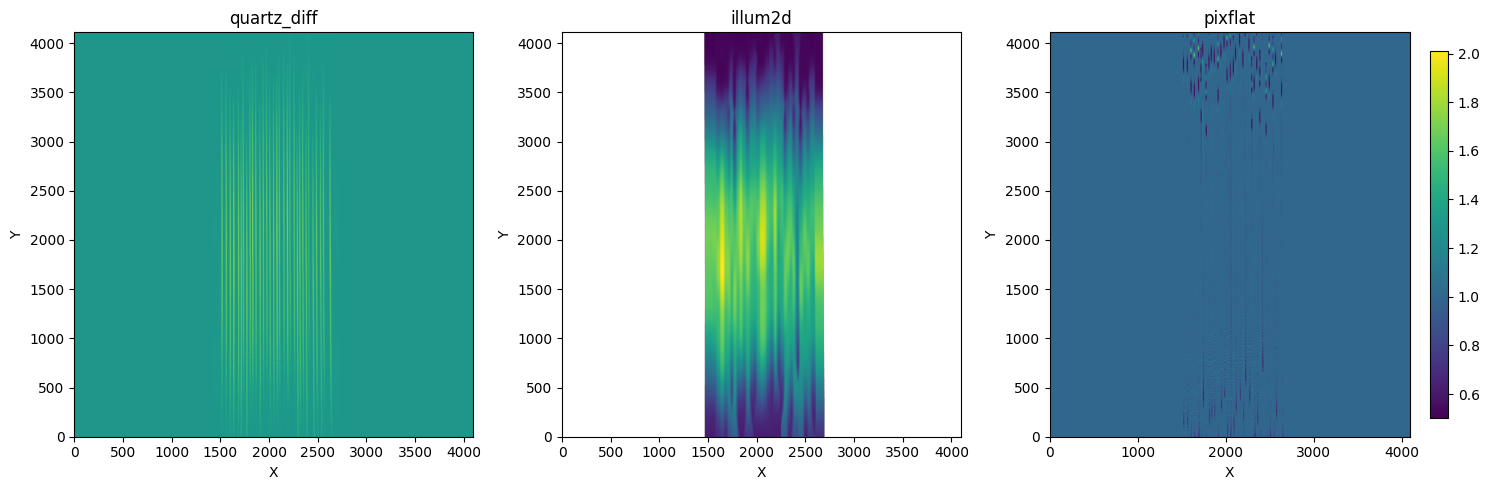

In [6]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

st05 = Path(config.ST05_PIXFLAT)

suffix = "even"   # change to "odd" for ODD

qfile = st05 / f"quartz_diff_{suffix}.fits"
ifile = st05 / f"illum2d_{suffix}.fits"

# Try canonical config name first, then fallback
if suffix == "even":
    pfile = Path(getattr(config, "PIXFLAT_EVEN", st05 / "PixelFlat_from_quartz_diff_EVEN.fits"))
else:
    pfile = Path(getattr(config, "PIXFLAT_ODD", st05 / "PixelFlat_from_quartz_diff_ODD.fits"))

quartz = fits.getdata(qfile)
illum2d = fits.getdata(ifile)
pixflat = fits.getdata(pfile)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(quartz, origin="lower", aspect="auto")
ax[0].set_title("quartz_diff")

ax[1].imshow(illum2d, origin="lower", aspect="auto")
ax[1].set_title("illum2d")

im = ax[2].imshow(pixflat, origin="lower", aspect="auto")
ax[2].set_title("pixflat")
plt.colorbar(im, ax=ax[2], fraction=0.046)

for a in ax:
    a.set_xlabel("X")
    a.set_ylabel("Y")

plt.tight_layout()


## 8. Recommended QC

The Step05 QC script writes products under:

- `config.ST05_PIXFLAT / "qc_step05_even"`
- `config.ST05_PIXFLAT / "qc_step05_odd"`

It generates:

- pixflat histograms
- image panels
- row-median plots
- summary text files

### Canonical QC command

```bash
PYTHONPATH=. python qc/step05/qc_step05_pixflat.py
```


In [8]:
# Uncomment to run Step05 QC
run_repo_script("qc/step05/qc_step05_pixflat.py")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step05/qc_step05_pixflat.py
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline

[EVEN] Pixflat stats:
 median = 1.0000
 std    = 0.1399
 min/max= 0.5032 / 2.0127
[DONE] QC written to /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/05_pixflat/qc_step05_even

[ODD] Pixflat stats:
 median = 1.0000
 std    = 0.1365
 min/max= 0.5028 / 2.0113
[DONE] QC written to /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step05/qc_step05_pixflat.py'], returncode=0)

## 9. Display the QC image panels

These are usually the most useful QC artifacts to embed in the notebook:

- `qc_step05_even/images_even.png`
- `qc_step05_odd/images_odd.png`


Displaying: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/05_pixflat/qc_step05_even/images_even.png


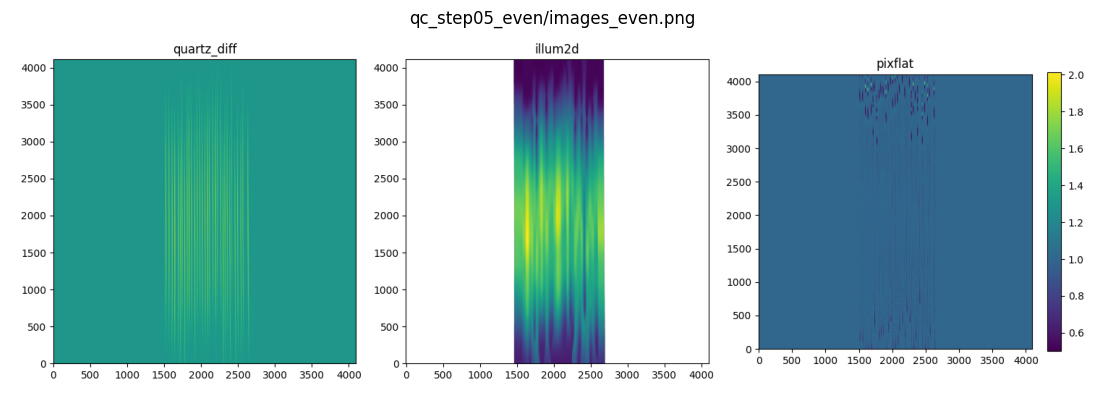

Displaying: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/05_pixflat/qc_step05_odd/images_odd.png


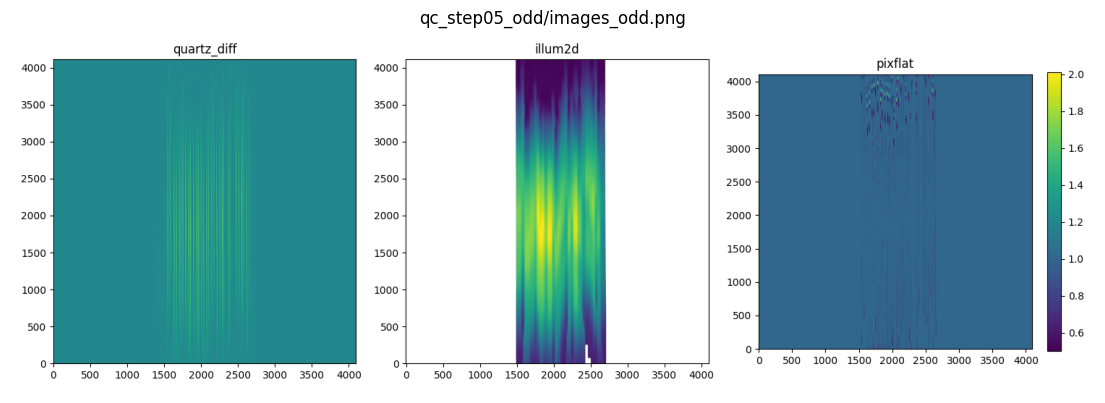

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

st05 = Path(config.ST05_PIXFLAT)

candidates = [
    st05 / "qc_step05_even" / "images_even.png",
    st05 / "qc_step05_odd" / "images_odd.png",
]

for p in candidates:
    if p.exists():
        print("Displaying:", p)
        img = Image.open(p)
        plt.figure(figsize=(14, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(str(p.relative_to(st05)))
        plt.show()
    else:
        print("Not found:", p)


## 10. Check pixflat statistics inside the slit mask

The most relevant statistics are the values **inside the Step04 slit footprint**, not over the whole detector.

A healthy pixflat should have:

- median close to 1
- modest scatter
- no large pathological excursions inside the valid slit regions


In [10]:
from astropy.io import fits
import numpy as np
from pathlib import Path

st04 = Path(config.ST04_TRACES)
st05 = Path(config.ST05_PIXFLAT)

def load_mask(trace_base):
    reg = st04 / f"{trace_base}_mask_reg.fits"
    if reg.exists():
        return fits.getdata(reg) > 0
    return fits.getdata(st04 / f"{trace_base}_mask.fits") > 0

for trace_set, trace_base, pfile in [
    ("EVEN", "Even_traces", Path(getattr(config, "PIXFLAT_EVEN", st05 / "PixelFlat_from_quartz_diff_EVEN.fits"))),
    ("ODD",  "Odd_traces",  Path(getattr(config, "PIXFLAT_ODD",  st05 / "PixelFlat_from_quartz_diff_ODD.fits"))),
]:
    if not pfile.exists():
        print(f"{trace_set}: not found -> {pfile}")
        continue

    mask = load_mask(trace_base)
    pixflat = fits.getdata(pfile)
    vals = pixflat[mask & np.isfinite(pixflat)]

    print(f"\n[{trace_set}]")
    print("median =", float(np.nanmedian(vals)))
    print("std    =", float(np.nanstd(vals)))
    print("min    =", float(np.nanmin(vals)))
    print("max    =", float(np.nanmax(vals)))
    print("p1/p99 =", float(np.nanpercentile(vals, 1)), float(np.nanpercentile(vals, 99)))



[EVEN]
median = 1.0
std    = 0.14741429686546326
min    = 0.5023606419563293
max    = 2.0094425678253174
p1/p99 = 0.5023606419563293 1.2156363725662234

[ODD]
median = 1.0
std    = 0.14681828022003174
min    = 0.5019883513450623
max    = 2.007953405380249
p1/p99 = 0.5019883513450623 1.2882338380813585


In [12]:
print("=== Step05 sanity check ===")

if 0.9 < np.nanmedian(vals) < 1.1:
    print("Median OK")
else:
    print("WARNING: median off")

if np.nanstd(vals) < 0.1:
    print("Scatter OK")
else:
    print("WARNING: high scatter")

print("Done.")

=== Step05 sanity check ===
Median OK
Done.


## 11. What Step05 is not doing

It is useful to state this explicitly.

Step05 is **not**:

- rectifying slitlets
- identifying sources
- tracing object ridges
- deriving wavelength solutions
- correcting large-scale slit throughput in science spectra directly

It is only building the **pixel flat**, i.e. the detector small-scale correction image.


## 12. What a good Step05 result should look like

Good behavior usually means:

- `quartz_diff` shows the expected slit illumination
- `illum2d` captures only the broad low-frequency structure
- `pixflat` is centered around 1 inside the traces
- no large-scale gradients remain in the final flat
- row medians stay close to 1
- the correction range is moderate and physically plausible

Typical warning signs are:

- strong residual large-scale structure in the pixflat
- noisy or unstable edges
- excessive clipping
- strong gradients in row medians
- obvious artifacts caused by a poor Step04 mask
